# Attention as information routing

Attention lets each position read a weighted mixture of other positions. We will compute one head by hand, apply a causal mask, and inspect how the output changes when one earlier value changes.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

Matplotlib is building the font cache; this may take a moment.


device: cpu


In [2]:
# Four positions, three-dimensional queries, keys, and values.
queries = torch.tensor([[1.,0.,0.],[0.,1.,0.],[1.,1.,0.],[0.,0.,1.]])
keys = torch.tensor([[1.,0.,0.],[0.,1.,0.],[1.,1.,0.],[0.,0.,1.]])
values = torch.tensor([[1.,0.],[0.,2.],[3.,1.],[0.,4.]])
scale = math.sqrt(keys.shape[-1])
scores = queries @ keys.T / scale
causal_mask = torch.tril(torch.ones(4,4,dtype=torch.bool))
masked_scores = scores.masked_fill(~causal_mask, float("-inf"))
weights = torch.softmax(masked_scores, dim=-1)
outputs = weights @ values
print("scores\n", scores)
print("causal weights\n", weights)
print("outputs\n", outputs)

scores
 

tensor([[0.5774, 0.0000, 0.5774, 0.0000],
        [0.0000, 0.5774, 0.5774, 0.0000],
        [0.5774, 0.5774, 1.1547, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.5774]])
causal weights
 tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.3595, 0.6405, 0.0000, 0.0000],
        [0.2645, 0.2645, 0.4711, 0.0000],
        [0.2091, 0.2091, 0.2091, 0.3726]])
outputs
 tensor([[1.0000, 0.0000],
        [0.3595, 1.2809],
        [1.6777, 1.0000],
        [0.8366, 2.1177]])


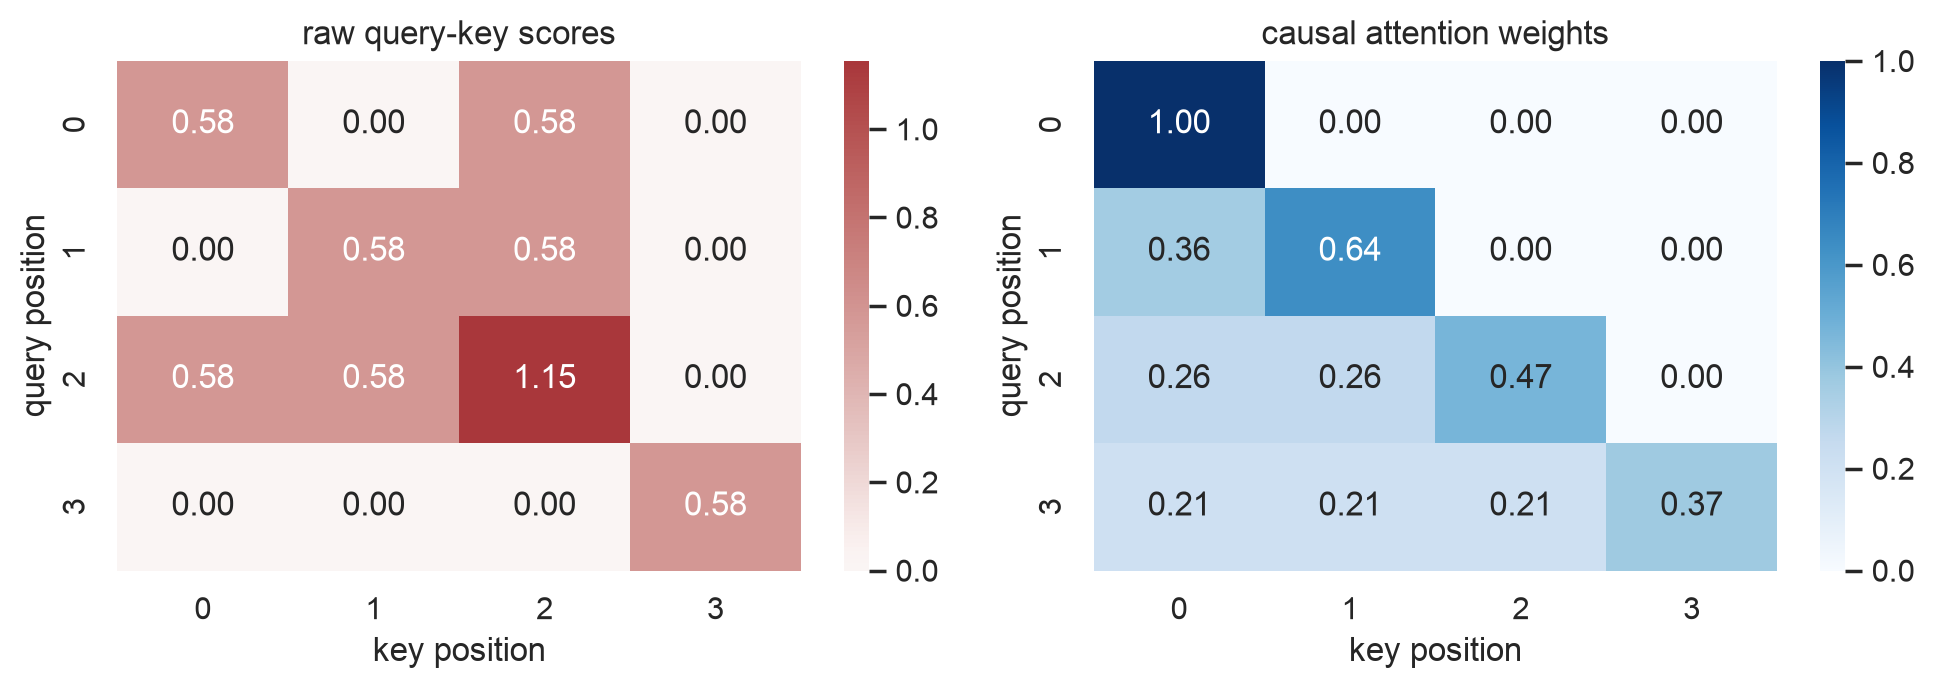

In [3]:
fig, axes = plt.subplots(1,2,figsize=(10,3.6))
sns.heatmap(scores, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0])
axes[0].set(title="raw query-key scores", xlabel="key position", ylabel="query position")
sns.heatmap(weights, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1])
axes[1].set(title="causal attention weights", xlabel="key position", ylabel="query position")
plt.tight_layout(); plt.show()

The mask makes the upper triangle inaccessible. Position 2 may read positions 0, 1, and 2, but never position 3. Softmax turns scores into rows that sum to one; the output at each position is a weighted average of values.

In [4]:
changed_values = values.clone(); changed_values[0] += torch.tensor([10., 0.])
changed_outputs = weights @ changed_values
print("change in outputs after modifying position 0:", (changed_outputs - outputs))

change in outputs after modifying position 0: tensor([[10.0000,  0.0000],
        [ 3.5954,  0.0000],
        [ 2.6446,  0.0000],
        [ 2.0915,  0.0000]])


## The notation

At one position, a query vector `q` represents the information this position is looking for. Every position supplies a key `k` used for matching and a value `v` used for the returned content. The score is `q·k / sqrt(d_k)`. Scaling keeps the dot products in a useful range as the key dimension grows; the row-wise softmax converts scores into mixing weights.

## Why causality matters

A language model is trained to predict the next token from the past. If position `t` could attend to position `t+1`, the target would leak into the input and the loss would no longer describe generation. The lower-triangular mask is therefore part of the model definition, not a visualization choice. Each row of the heatmap answers: which earlier positions can this prediction read?

## A useful mental model

Attention is a data-dependent weighted sum. A fixed convolution always uses the same local pattern; attention can put most of its weight on a different earlier position for every input. That flexibility is the reason it can express relationships such as a name referring back to a noun several positions earlier.

This is the key operation: queries decide what a position is looking for, keys describe what each position offers, and values carry the information that is mixed. The next notebook packages this calculation into a trainable PyTorch module.